In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, accuracy_score

random_state = 1
np.random.seed(random_state)
torch.manual_seed(random_state)

In [2]:
# Import data
touchpoints = pd.read_csv("customer_journey-4.csv")
sessions = pd.read_csv("results-3.csv")

In [3]:
# Visualise

In [4]:
touchpoints.head()

,user_id,session_id,order,channel,time_till_session_end
0,0,0,0,Google Display,0.0
1,0,1,0,Google Search,336.0
2,0,1,1,Organic,288.0
3,0,1,2,Organic,0.0
4,0,2,0,Google Search,120.0


In [5]:
sessions.head()

,user_id,session_id,conversion
0,0,0,1
1,0,1,1
2,0,2,0
3,0,3,0
4,0,4,1


In [6]:
print(touchpoints.shape)
print(sessions.shape)
print(sessions["user_id"].nunique())

(1179921, 5)
(510496, 3)
72959


In [7]:
# Preprocess

# Add target to sessions
sessions["target"] = (
    sessions.groupby("user_id")["conversion"]
    .shift(-1)
    .astype("Int64")
)

# Identify each customer's final session
last_sessions = (
    sessions.groupby("user_id")["session_id"]
    .max()
    .reset_index()
    .rename(columns={"session_id": "last_session_id"})
)

# Remove final sessions from sessions
sessions = sessions.merge(last_sessions, on="user_id")
sessions = sessions[
    sessions["session_id"] != sessions["last_session_id"]
].drop(columns="last_session_id")

# Remove final sessions from touchpoints
touchpoints = touchpoints.merge(last_sessions, on="user_id")
touchpoints = touchpoints[
    touchpoints["session_id"] != touchpoints["last_session_id"]
].drop(columns="last_session_id")

# Convert time_till_session_end to time_elapsed
touchpoints["time_elapsed"] = (
    touchpoints.groupby(["user_id", "session_id"])["time_till_session_end"]
    .transform("max")
    - touchpoints["time_till_session_end"]
).astype(int)
touchpoints = touchpoints.drop(columns="time_till_session_end")

# Add last_touchpoint indicator
touchpoints["last_touchpoint"] = (
    touchpoints["order"]
    == touchpoints.groupby(["user_id", "session_id"])["order"].transform("max")
).astype(int)

# One-hot-encode channel
touchpoints = pd.get_dummies(
    touchpoints,
    columns=["channel"],
    dtype=int
)

In [8]:
# Visualise

In [9]:
touchpoints.head()

,user_id,session_id,order,time_elapsed,last_touchpoint,channel_Direct,channel_Email Marketing,channel_Facebook,channel_Google Display,channel_Google Search,channel_Instagram,channel_Organic,channel_Youtube
0,0,0,0,0,1,0,0,0,1,0,0,0,0
1,0,1,0,0,0,0,0,0,0,1,0,0,0
2,0,1,1,48,0,0,0,0,0,0,0,1,0
3,0,1,2,336,1,0,0,0,0,0,0,1,0
4,0,2,0,0,0,0,0,0,0,1,0,0,0


In [10]:
sessions.head()

,user_id,session_id,conversion,target
0,0,0,1,1
1,0,1,1,0
2,0,2,0,0
3,0,3,0,1
5,11,0,1,0


In [11]:
print(touchpoints.shape)
print(sessions.shape)
print(sessions["user_id"].nunique())

(1010949, 13)
(437537, 4)
72781


In [12]:
# Create train test split
test_size = 0.2

user_ids = sessions["user_id"].unique()

train_users, test_users = train_test_split(
    user_ids,
    test_size=test_size,
    random_state=random_state
)

touchpoints_train = touchpoints[touchpoints["user_id"].isin(train_users)].copy()
touchpoints_test = touchpoints[touchpoints["user_id"].isin(test_users)].copy()

sessions_train = sessions[sessions["user_id"].isin(train_users)].copy()
sessions_test = sessions[sessions["user_id"].isin(test_users)].copy()

In [13]:
# Normalise
scaler = StandardScaler()

touchpoints_train[["order_norm", "time_elapsed"]] = scaler.fit_transform(touchpoints_train[["order", "time_elapsed"]])
touchpoints_test[["order_norm", "time_elapsed"]] = scaler.transform(touchpoints_test[["order", "time_elapsed"]])
touchpoints_test = touchpoints_test.reset_index(drop=True)

sessions_train["session_id_norm"] = scaler.fit_transform(sessions_train[["session_id"]])
sessions_test["session_id_norm"] = scaler.transform(sessions_test[["session_id"]])
sessions_test = sessions_test.reset_index(drop=True)

In [14]:
# Visualise

In [15]:
touchpoints_train.head()

,user_id,session_id,order,time_elapsed,last_touchpoint,channel_Direct,channel_Email Marketing,channel_Facebook,channel_Google Display,channel_Google Search,channel_Instagram,channel_Organic,channel_Youtube,order_norm
0,0,0,0,-0.641439,1,0,0,0,1,0,0,0,0,-0.752753
1,0,1,0,-0.641439,0,0,0,0,0,1,0,0,0,-0.752753
2,0,1,1,-0.451159,0,0,0,0,0,0,0,1,0,-0.198961
3,0,1,2,0.690524,1,0,0,0,0,0,0,1,0,0.354830
4,0,2,0,-0.641439,0,0,0,0,0,1,0,0,0,-0.752753


In [16]:
touchpoints_test.head()

,user_id,session_id,order,time_elapsed,last_touchpoint,channel_Direct,channel_Email Marketing,channel_Facebook,channel_Google Display,channel_Google Search,channel_Instagram,channel_Organic,channel_Youtube,order_norm
0,70,0,0,-0.641439,1,1,0,0,0,0,0,0,0,-0.752753
1,70,1,0,-0.641439,0,0,0,0,1,0,0,0,0,-0.752753
2,70,1,1,-0.070598,0,0,0,0,0,0,0,1,0,-0.198961
3,70,1,2,0.119683,1,0,0,0,0,0,0,1,0,0.354830
4,70,2,0,-0.641439,0,0,0,0,0,1,0,0,0,-0.752753


In [17]:
sessions_train.head()

,user_id,session_id,conversion,target,session_id_norm
0,0,0,1,1,-1.223554
1,0,1,1,0,-0.815633
2,0,2,0,0,-0.407713
3,0,3,0,1,0.000207
5,11,0,1,0,-1.223554


In [18]:
sessions_test.head()

,user_id,session_id,conversion,target,session_id_norm
0,70,0,0,1,-1.223554
1,70,1,1,0,-0.815633
2,70,2,0,1,-0.407713
3,70,3,1,1,0.000207
4,70,4,1,1,0.408128


In [19]:
# Create dataset class

channel_cols = [
    col for col in touchpoints_train.columns
    if col.startswith("channel_")
]

touchpoint_cols = [
    "order_norm",
    "time_elapsed",
    "last_touchpoint",
    *channel_cols
]

session_cols = [
    "session_id_norm",
    "conversion"
]

def preprocess_dataset(touchpoints, sessions):

    customers = []

    touchpoint_groups = touchpoints.groupby(
        ["user_id", "session_id"],
        sort=False
    )

    session_groups = sessions.groupby(
        "user_id",
        sort=False
    )

    for user_id, user_sessions in session_groups:

        touchpoint_tensor = []

        for session_id in user_sessions["session_id"]:

            session_tp = touchpoint_groups.get_group(
                (user_id, session_id)
            )

            x = torch.from_numpy(
                session_tp[touchpoint_cols]
                .values
                .astype("float32")
            )

            touchpoint_tensor.append(x)

        session_tensor = torch.from_numpy(
            user_sessions[session_cols]
            .values
            .astype("float32")
        )

        target_tensor = torch.from_numpy(
            user_sessions["target"]
            .values
            .astype("float32")
        )

        customers.append({
            "touchpoint_tensor": touchpoint_tensor,
            "session_tensor": session_tensor,
            "target_tensor": target_tensor
        })

    return customers

In [20]:
train_customers = preprocess_dataset(
    touchpoints_train,
    sessions_train
)

test_customers = preprocess_dataset(
    touchpoints_test,
    sessions_test
)

In [21]:
class CustomerDataset(Dataset):

    def __init__(self, customers):
        self.customers = customers

    def __len__(self):
        return len(self.customers)

    def __getitem__(self, idx):
        return self.customers[idx]

In [22]:
train_dataset = CustomerDataset(train_customers)
test_dataset = CustomerDataset(test_customers)

In [23]:
# Collate function to deal with varying sequence lengths

def collate_fn(batch):

    batch_size = len(batch)

    # Maximum number of sessions in this batch
    max_sessions = max(
        len(customer["touchpoint_tensor"])
        for customer in batch
    )

    # Maximum number of touchpoints in any session in this batch
    max_touchpoints = max(
        session.shape[0]
        for customer in batch
        for session in customer["touchpoint_tensor"]
    )

    # Number of touchpoint/session features
    D_touch = batch[0]["touchpoint_tensor"][0].shape[1]
    D_session = batch[0]["session_tensor"].shape[1]

    # Allocate padded tensors

    touchpoint_tensor = torch.zeros(
        batch_size,
        max_sessions,
        max_touchpoints,
        D_touch
    )

    session_tensor = torch.zeros(
        batch_size,
        max_sessions,
        D_session
    )

    target_tensor = torch.zeros(
        batch_size,
        max_sessions
    )

    # Masks: True = real data, False = padding
    touchpoint_mask = torch.zeros(
        batch_size,
        max_sessions,
        max_touchpoints,
        dtype=torch.bool
    )

    session_mask = torch.zeros(
        batch_size,
        max_sessions,
        dtype=torch.bool
    )

    # Fill tensors

    for i, customer in enumerate(batch):

        n_sessions = len(customer["touchpoint_tensor"])

        for j in range(n_sessions):

            session = customer["touchpoint_tensor"][j]

            n_touchpoints = session.shape[0]

            touchpoint_tensor[
                i, j, :n_touchpoints, :
            ] = session

            touchpoint_mask[
                i, j, :n_touchpoints
            ] = True

        session_tensor[
            i, :n_sessions, :
        ] = customer["session_tensor"]

        target_tensor[
            i, :n_sessions
        ] = customer["target_tensor"]

        session_mask[
            i, :n_sessions
        ] = True

    return {
        "touchpoint_tensor": touchpoint_tensor,
        "touchpoint_mask": touchpoint_mask,
        "session_tensor": session_tensor,
        "session_mask": session_mask,
        "target_tensor": target_tensor
    }

In [24]:
# Create dataloaders

batch_size = 512

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn
)

In [25]:
# Define model class

class CustomerJourneyModel(nn.Module):

    def __init__(
        self,
        touchpoint_input_size,
        session_input_size,
        touchpoint_hidden_size=32,
        session_hidden_size=32,
        touchpoint_num_layers=1,
        session_num_layers=1
    ):
        super().__init__()

        # First LSTM: touchpoints → session representation
        self.touchpoint_lstm = nn.LSTM(
            input_size=touchpoint_input_size,
            hidden_size=touchpoint_hidden_size,
            num_layers=touchpoint_num_layers,
            batch_first=True
        )

        # Second LSTM: session representations → customer history
        self.session_lstm = nn.LSTM(
            input_size=touchpoint_hidden_size + session_input_size,
            hidden_size=session_hidden_size,
            num_layers=session_num_layers,
            batch_first=True
        )

        # Predict next-session conversion probability
        self.output_layer = nn.Linear(
            session_hidden_size,
            1
        )

    def forward(
        self,
        touchpoint_tensor,
        touchpoint_mask,
        session_tensor,
        session_mask
    ):
    
        batch_size = touchpoint_tensor.size(0)
        max_sessions = touchpoint_tensor.size(1)
        max_touchpoints = touchpoint_tensor.size(2)
    
        # --------------------------------------------------
        # First LSTM: touchpoints → session representations
        # --------------------------------------------------
    
        # Flatten batch and session dimensions
        x = touchpoint_tensor.view(
            batch_size * max_sessions,
            max_touchpoints,
            -1
        )
    
        # Run all padded touchpoint sequences
        output, _ = self.touchpoint_lstm(x)
    
        # Reshape back to [batch, sessions, touchpoints, hidden]
        output = output.view(
            batch_size,
            max_sessions,
            max_touchpoints,
            -1
        )
    
        # --------------------------------------------------
        # Select the final real touchpoint from each session
        # --------------------------------------------------
    
        # Number of real touchpoints - 1 gives the final index
        lengths = touchpoint_mask.sum(dim=2) - 1
    
        # Padded sessions have length -1, so clamp them to 0.
        # Their outputs will be ignored later using session_mask.
        lengths = lengths.clamp(min=0)
    
        batch_indices = torch.arange(
            batch_size,
            device=touchpoint_tensor.device
        )[:, None]
    
        session_indices = torch.arange(
            max_sessions,
            device=touchpoint_tensor.device
        )[None, :]
    
        session_vectors = output[
            batch_indices,
            session_indices,
            lengths
        ]
    
        # --------------------------------------------------
        # Add session-level features
        # --------------------------------------------------
    
        session_inputs = torch.cat(
            [session_vectors, session_tensor],
            dim=2
        )
    
        # --------------------------------------------------
        # Second LSTM: session history
        # --------------------------------------------------
    
        # Process the full padded session sequence
        session_output, _ = self.session_lstm(
            session_inputs
        )
    
        # --------------------------------------------------
        # Predict next-session conversion
        # --------------------------------------------------
    
        logits = self.output_layer(session_output).squeeze(-1)

        return logits

In [26]:
# Instantiate model

touchpoint_input_size = len(touchpoint_cols)
session_input_size = len(session_cols)

model = CustomerJourneyModel(
    touchpoint_input_size=touchpoint_input_size,
    session_input_size=session_input_size,
    touchpoint_hidden_size=32,
    session_hidden_size=32,
    touchpoint_num_layers=1,
    session_num_layers=1
)

In [27]:
# Define criterion and optimiser

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [28]:
# Training loop

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = model.to(device)
print("Device:", str(device))

num_epochs = 20

for epoch in range(num_epochs):

    model.train()

    total_loss = 0

    for batch_idx, batch in enumerate(train_loader):

        # Move batch to device
        touchpoint_tensor = batch["touchpoint_tensor"].to(device)
        touchpoint_mask = batch["touchpoint_mask"].to(device)
        session_tensor = batch["session_tensor"].to(device)
        session_mask = batch["session_mask"].to(device)
        target_tensor = batch["target_tensor"].to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        logits = model(
            touchpoint_tensor,
            touchpoint_mask,
            session_tensor,
            session_mask
        )

        # Only calculate loss for real sessions
        loss = criterion(
            logits[session_mask],
            target_tensor[session_mask]
        )

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        total_loss += loss.item()

        if (batch_idx + 1) % 10 == 0:
            print(
                f"Epoch [{epoch + 1}/{num_epochs}], "
                f"Batch [{batch_idx + 1}/{len(train_loader)}], "
                f"Loss: {loss.item():.4f}"
            )

    # Average loss over batches
    average_loss = total_loss / len(train_loader)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}], "
        f"Loss: {average_loss:.4f}"
    )

Device: mps
Epoch [1/20], Batch [10/114], Loss: 0.6901
Epoch [1/20], Batch [20/114], Loss: 0.6828
Epoch [1/20], Batch [30/114], Loss: 0.6785
Epoch [1/20], Batch [40/114], Loss: 0.6778
Epoch [1/20], Batch [50/114], Loss: 0.6746
Epoch [1/20], Batch [60/114], Loss: 0.6813
Epoch [1/20], Batch [70/114], Loss: 0.6779
Epoch [1/20], Batch [80/114], Loss: 0.6776
Epoch [1/20], Batch [90/114], Loss: 0.6813
Epoch [1/20], Batch [100/114], Loss: 0.6825
Epoch [1/20], Batch [110/114], Loss: 0.6732
Epoch [1/20], Loss: 0.6816
Epoch [2/20], Batch [10/114], Loss: 0.6744
Epoch [2/20], Batch [20/114], Loss: 0.6801
Epoch [2/20], Batch [30/114], Loss: 0.6812
Epoch [2/20], Batch [40/114], Loss: 0.6786
Epoch [2/20], Batch [50/114], Loss: 0.6786
Epoch [2/20], Batch [60/114], Loss: 0.6780
Epoch [2/20], Batch [70/114], Loss: 0.6762
Epoch [2/20], Batch [80/114], Loss: 0.6794
Epoch [2/20], Batch [90/114], Loss: 0.6816
Epoch [2/20], Batch [100/114], Loss: 0.6836
Epoch [2/20], Batch [110/114], Loss: 0.6766
Epoch [2/20

In [29]:
# Evaluate model

def evaluate_model(model, loader, criterion, device):

    model.eval()

    total_loss = 0

    all_targets = []
    all_probabilities = []

    with torch.no_grad():

        for batch in loader:

            touchpoint_tensor = batch["touchpoint_tensor"].to(device)
            touchpoint_mask = batch["touchpoint_mask"].to(device)
            session_tensor = batch["session_tensor"].to(device)
            session_mask = batch["session_mask"].to(device)
            target_tensor = batch["target_tensor"].to(device)

            logits = model(
                touchpoint_tensor,
                touchpoint_mask,
                session_tensor,
                session_mask
            )

            # Only use real sessions
            logits_valid = logits[session_mask]
            targets_valid = target_tensor[session_mask]

            # Loss
            loss = criterion(
                logits_valid,
                targets_valid
            )

            total_loss += loss.item()

            # Convert logits to probabilities
            probabilities = torch.sigmoid(logits_valid)

            # Store for ROC-AUC
            all_targets.append(
                targets_valid.cpu()
            )

            all_probabilities.append(
                probabilities.cpu()
            )

    average_loss = total_loss / len(loader)

    all_targets = torch.cat(all_targets).numpy()
    all_probabilities = torch.cat(all_probabilities).numpy()

    return (
        average_loss,
        all_targets,
        all_probabilities
    )

In [30]:
train_loss, _, _ = evaluate_model(
    model,
    train_loader,
    criterion,
    device
)

test_loss, test_targets, test_probabilities = evaluate_model(
    model,
    test_loader,
    criterion,
    device
)

In [31]:
roc_auc = roc_auc_score(
    test_targets,
    test_probabilities
)

In [32]:
print(f"Train Loss:     {train_loss:.4f}")
print(f"Test Loss:      {test_loss:.4f}")
print()
print(f"Test ROC-AUC: {roc_auc:.4f}")

Train Loss:     0.6778
Test Loss:      0.6782

Test ROC-AUC: 0.5189


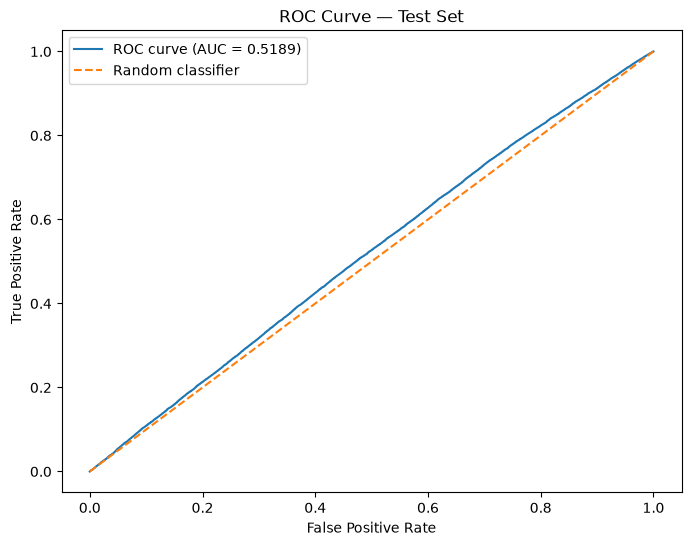

In [33]:
fpr, tpr, thresholds = roc_curve(
    test_targets,
    test_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC curve (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Test Set")
plt.legend()
plt.show()

In [34]:
def calculate_rates(test_targets, test_probabilities, threshold):

    # Convert probabilities to predictions at the chosen threshold
    test_predictions = (
        test_probabilities >= threshold
    ).astype(int)

    # Confusion matrix
    cm = confusion_matrix(
        test_targets,
        test_predictions
    )

    tn, fp, fn, tp = cm.ravel()

    # Rates
    true_positive_rate = tp / (tp + fn)
    false_positive_rate = fp / (fp + tn)

        # Accuracy
    accuracy = accuracy_score(
        test_targets,
        test_predictions
    )

    print(f"Threshold:           {threshold:.4f}")
    print()
    print(f"True Negatives:      {tn}")
    print(f"False Positives:     {fp}")
    print(f"False Negatives:     {fn}")
    print(f"True Positives:      {tp}")
    print()
    print(f"Accuracy:            ~{accuracy:.2%}")
    print(f"True Positive Rate:  ~{true_positive_rate:.2%}")
    print(f"False Positive Rate: ~{false_positive_rate:.2%}")

In [35]:
calculate_rates(
    test_targets,
    test_probabilities,
    threshold=0.5
)

Threshold:           0.5000

True Negatives:      0
False Positives:     36256
False Negatives:     0
True Positives:      51032

Accuracy:            ~58.46%
True Positive Rate:  ~100.00%
False Positive Rate: ~100.00%


In [36]:
fpr, tpr, thresholds = roc_curve(
    test_targets,
    test_probabilities
)

# Distance from ideal point (0, 1)
distances = np.sqrt(
    fpr**2 + (1 - tpr)**2
)

best_index = np.argmin(distances)

best_threshold = thresholds[best_index]

print(f"Best threshold: {best_threshold:.4f}")

Best threshold: 0.5890


In [37]:
calculate_rates(
    test_targets,
    test_probabilities,
    threshold=best_threshold
)

Threshold:           0.5890

True Negatives:      18761
False Positives:     17495
False Negatives:     24960
True Positives:      26072

Accuracy:            ~51.36%
True Positive Rate:  ~51.09%
False Positive Rate: ~48.25%
